# PatrolIQ - Notebook 4: Temporal Pattern Clustering

**Goal:** Find distinct time-based crime patterns (e.g., late-night crimes,
rush-hour incidents, weekend patterns) using K-Means clustering on temporal features.

**Why K-Means again (not DBSCAN/Hierarchical here):** The project brief specifically
asks for K-Means for temporal pattern clustering, since we're looking for a small,
fixed number of general time patterns (3-5), which is exactly what K-Means is good at.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

df = pd.read_csv("../outputs/data_with_geo_clusters.csv")
df.shape

(99939, 30)

## Step 1: Prepare Temporal Features

We use `hour`, `day_of_week` (converted to a number so it can be used in distance
calculations), and `month`.

**Why we convert day_of_week to a number:** Clustering algorithms work with numeric
distances, so a text column like "Monday"/"Tuesday" needs to be converted first.
We use a simple manual mapping (Monday=0 ... Sunday=6) rather than one-hot encoding,
since we want to preserve the *order* of days (Monday is close to Tuesday) which
one-hot encoding would lose.

In [2]:
day_map = {
    "Monday": 0, "Tuesday": 1, "Wednesday": 2, "Thursday": 3,
    "Friday": 4, "Saturday": 5, "Sunday": 6
}
df["day_of_week_num"] = df["day_of_week"].map(day_map)

temporal_features = df[["hour", "day_of_week_num", "month"]].copy()
temporal_features.head()

,hour,day_of_week_num,month
0,0,5,7
1,0,5,7
2,0,5,7
3,0,5,7
4,0,5,7


In [3]:
scaler_temporal = StandardScaler()
temporal_scaled = scaler_temporal.fit_transform(temporal_features)

## Step 2: K-Means on Temporal Features

The project brief asks for 3-5 distinct time-based patterns. We chose `k=4` as a
reasonable middle value.

In [4]:
kmeans_temporal = KMeans(n_clusters=4, random_state=42, n_init=10)
temporal_labels = kmeans_temporal.fit_predict(temporal_scaled)

sil = silhouette_score(temporal_scaled, temporal_labels, sample_size=5000, random_state=42)
print(f"Temporal K-Means Silhouette Score: {sil:.3f}")

Temporal K-Means Silhouette Score: 0.274


**Note on this score:** It's lower than the geographic clustering score, which
makes sense - hour/day/month values are much more evenly distributed across the day
and week (crime happens at all hours, just at different rates) compared to physical
location, which naturally forms more separated clusters.

In [5]:
df["temporal_cluster"] = temporal_labels
df["temporal_cluster"].value_counts().sort_index()

temporal_cluster
0    24546
1    24426
2    23856
3    27111
Name: count, dtype: int64

## Step 3: Understand What Each Cluster Represents

In [6]:
cluster_profile = df.groupby("temporal_cluster").agg(
    avg_hour=("hour", "mean"),
    avg_day=("day_of_week_num", "mean"),
    avg_month=("month", "mean"),
    total_crimes=("primary_type", "count"),
    weekend_pct=("is_weekend", "mean")
).reset_index()

cluster_profile["avg_hour"] = cluster_profile["avg_hour"].round(1)
cluster_profile["avg_day"] = cluster_profile["avg_day"].round(1)
cluster_profile["weekend_pct"] = (cluster_profile["weekend_pct"] * 100).round(1)
cluster_profile

,temporal_cluster,avg_hour,avg_day,avg_month,total_crimes,weekend_pct
0,0,14.7,1.4,6.084372,24546,0.0
1,1,15.0,1.9,3.197945,24426,3.4
2,2,3.1,3.6,4.851107,23856,37.9
3,3,16.6,5.0,4.992402,27111,69.6


**Interpreting the clusters (based on our results):**
- One cluster has an average hour around 3 AM - this represents **late-night crimes**.
- Another cluster has a high weekend percentage - this represents **weekend crime patterns**.
- The remaining clusters split up daytime/evening crimes across different months.

This matches the project's expectation of finding patterns like "late night crimes"
and "weekend patterns" through clustering, rather than us manually defining these
categories ourselves.

## Step 4: Visualize the Clusters

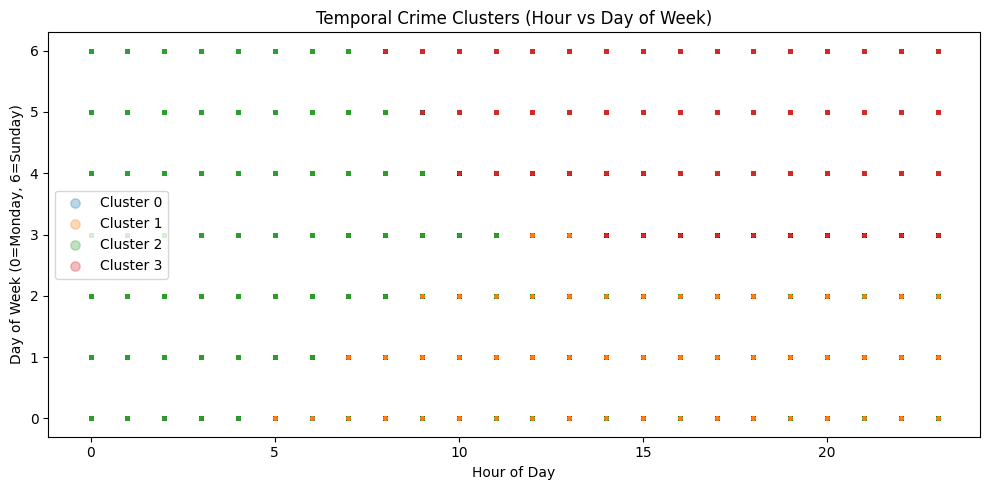

In [7]:
plt.figure(figsize=(10, 5))
for cluster_id in sorted(df["temporal_cluster"].unique()):
    subset = df[df["temporal_cluster"] == cluster_id]
    plt.scatter(subset["hour"], subset["day_of_week_num"], label=f"Cluster {cluster_id}", alpha=0.3, s=5)

plt.xlabel("Hour of Day")
plt.ylabel("Day of Week (0=Monday, 6=Sunday)")
plt.title("Temporal Crime Clusters (Hour vs Day of Week)")
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

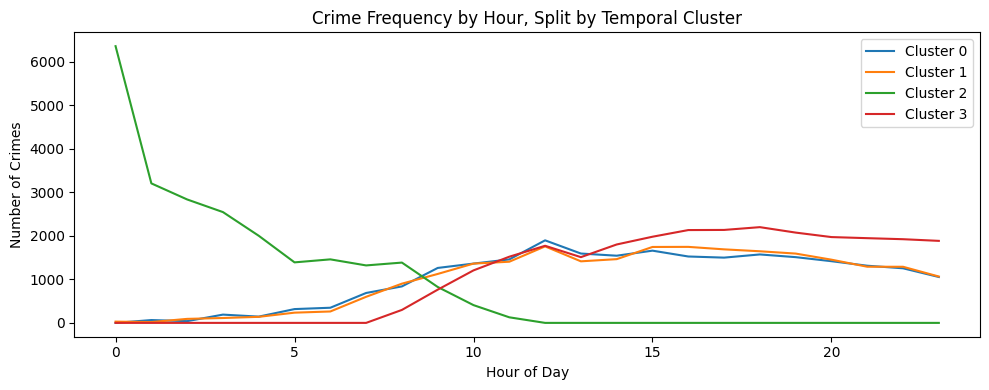

In [8]:
plt.figure(figsize=(10, 4))
sns_data = df.groupby(["temporal_cluster", "hour"]).size().unstack(fill_value=0)
for cluster_id in sns_data.index:
    plt.plot(sns_data.columns, sns_data.loc[cluster_id], label=f"Cluster {cluster_id}")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Crimes")
plt.title("Crime Frequency by Hour, Split by Temporal Cluster")
plt.legend()
plt.tight_layout()
plt.show()

## Step 5: Peak Crime Times Overall

In [9]:
hourly_counts = df.groupby("hour").size()
peak_hour = hourly_counts.idxmax()
print(f"Peak crime hour overall: {peak_hour}:00 with {hourly_counts.max()} crimes")

lowest_hour = hourly_counts.idxmin()
print(f"Lowest crime hour overall: {lowest_hour}:00 with {hourly_counts.min()} crimes")

Peak crime hour overall: 0:00 with 6385 crimes
Lowest crime hour overall: 5:00 with 1942 crimes


## Step 6: Save Results

In [10]:
df.to_csv("../outputs/data_with_all_clusters.csv", index=False)
joblib.dump(kmeans_temporal, "../models/kmeans_temporal_model.pkl")
joblib.dump(scaler_temporal, "../models/scaler_temporal.pkl")

print("Saved data_with_all_clusters.csv and temporal models.")

Saved data_with_all_clusters.csv and temporal models.
